## Notebook goal

Try to classify a comment as toxic/non-toxic (Insult) as a first classification model.
Learn why and how to do classified supervised learning on NPL feature.

## Understanding the dataset

In [18]:
import matplotlib
import pandas as pd

df = pd.read_csv("./resources/jigsaw_snapshot/data.csv")

df.head()

,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59856,0.893617,haha you guys are a bunch of losers.,0.021277,0.000000,0.021277,0.872340,0.0000,0.0,0.0,...,2006,rejected,0,0,0,1,0,0.000000,4,47
1,239607,0.912500,Yet call out all Muslims for the acts of a few...,0.050000,0.237500,0.612500,0.887500,0.1125,0.0,0.0,...,26670,approved,0,0,0,1,0,0.000000,4,80
2,239612,0.830769,This bitch is nuts. Who would read a book by a...,0.107692,0.661538,0.338462,0.830769,0.0000,0.0,0.0,...,26674,rejected,0,0,0,0,0,0.061538,4,65
3,240311,0.968750,You're an idiot.,0.031250,0.062500,0.000000,0.968750,0.0000,NaN,NaN,...,32846,rejected,0,0,0,0,0,0.000000,0,32
4,240329,0.900000,Who cares!? Stark trek and Star Wars fans are ...,0.100000,0.200000,0.000000,0.900000,0.0000,NaN,NaN,...,32846,rejected,0,0,0,0,0,0.300000,0,10


The output shows many columns related to characteristics related to identity and bias to study how toxicity notes are related to some identities.

So, for this notebook, I'll only take `comment_text` column as feature and I'll create a new feature as target based on `toxicity` feature, If `target` (percentage of the scores who checked and classified it as toxic comment ) > 55% then the comment will be toxic.

## EDA

First lets explore the dataset to get a general view of it.

In [19]:
df.shape

(90902, 45)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90902 entries, 0 to 90901
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   90902 non-null  int64  
 1   target                               90902 non-null  float64
 2   comment_text                         90902 non-null  str    
 3   severe_toxicity                      90902 non-null  float64
 4   obscene                              90902 non-null  float64
 5   identity_attack                      90902 non-null  float64
 6   insult                               90902 non-null  float64
 7   threat                               90902 non-null  float64
 8   asian                                21687 non-null  float64
 9   atheist                              21687 non-null  float64
 10  bisexual                             21687 non-null  float64
 11  black                                21

In [21]:
na_values = df.isna().mean() * 100
na_values[na_values > 0]

asian                                  76.142439
atheist                                76.142439
bisexual                               76.142439
black                                  76.142439
buddhist                               76.142439
christian                              76.142439
female                                 76.142439
heterosexual                           76.142439
hindu                                  76.142439
homosexual_gay_or_lesbian              76.142439
intellectual_or_learning_disability    76.142439
jewish                                 76.142439
latino                                 76.142439
male                                   76.142439
muslim                                 76.142439
other_disability                       76.142439
other_gender                           76.142439
other_race_or_ethnicity                76.142439
other_religion                         76.142439
other_sexual_orientation               76.142439
physical_disability 

In [22]:
((df.shape[0] - df.nunique()) / df.shape[0]) * 100

id                                      0.000000
target                                 98.435678
comment_text                            0.840466
severe_toxicity                        98.723900
obscene                                97.741524
identity_attack                        98.071550
insult                                 97.753625
threat                                 98.371873
asian                                  99.974698
atheist                                99.979098
bisexual                               99.979098
black                                  99.969198
buddhist                               99.981299
christian                              99.965897
female                                 99.963697
heterosexual                           99.971398
hindu                                  99.983499
homosexual_gay_or_lesbian              99.975798
intellectual_or_learning_disability    99.984599
jewish                                 99.979098
latino              

In [23]:
df.describe()

,id,target,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,bisexual,...,parent_id,article_id,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
count,9.090200e+04,90902.000000,90902.000000,90902.000000,90902.000000,90902.000000,90902.000000,21687.00000,21687.000000,21687.000000,...,4.983000e+04,90902.000000,90902.000000,90902.000000,90902.000000,90902.000000,90902.000000,90902.000000,90902.000000,90902.000000
mean,3.741905e+06,0.430254,0.020783,0.091598,0.054786,0.381360,0.025486,0.01059,0.003179,0.001616,...,3.683063e+06,281545.713736,0.258938,0.043365,0.106741,2.334360,0.559207,0.023667,1.535489,36.632560
std,2.450000e+06,0.406086,0.043101,0.182411,0.147375,0.386545,0.109004,0.08227,0.051270,0.024006,...,2.458295e+06,104028.940513,0.994396,0.240804,0.453165,4.587831,1.735908,0.106960,18.199186,147.288485
min,5.985600e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,2.210600e+05,2006.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,7.921310e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,7.825040e+05,159937.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,5.232225e+06,0.500120,0.000000,0.000000,0.000000,0.200000,0.000000,0.00000,0.000000,0.000000,...,5.208236e+06,332720.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,6.000000
75%,5.785647e+06,0.810345,0.026316,0.116667,0.021739,0.785714,0.000000,0.00000,0.000000,0.000000,...,5.769276e+06,367055.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,58.000000
max,6.333872e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,6.333696e+06,399523.000000,58.000000,8.000000,16.000000,224.000000,96.000000,1.000000,1838.000000,4936.000000


We have a lot of duplicated values but these are in columns that right now I'm not going to use for anything, I'll only use `target` column with no NaN.

Lets create the feature `toxic`

In [24]:
df["toxic"] = (df["target"] >= 0.55)

df["toxic"].value_counts()

toxic
True     45451
False    45451
Name: count, dtype: int64

So now, lets see how `toxic` and `target` are distributed

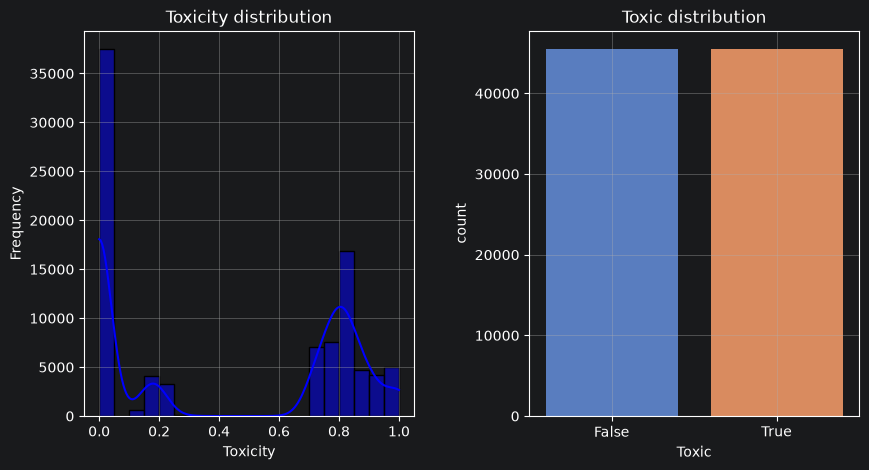

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2,figsize=(10,5))
sns.histplot(df["target"],bins=20,color='blue', kde=True, ax=ax0)
sns.countplot(data=df, x="toxic", hue="toxic", palette="muted", legend=False, ax=ax1)
ax0.set_title("Toxicity distribution")
ax0.set_xlabel("Toxicity")
ax0.set_ylabel("Frequency")
ax1.set_title("Toxic distribution")
ax1.set_xlabel("Toxic")
plt.subplots_adjust(wspace=0.35)
ax0.grid(True)
ax1.grid(True)
plt.show()

The histogram show us the target (toxicity) distribution, there is no middle point here, most of the comments are toxic or non-toxic as seen with the density curve, so our `toxic` target is balanced as shown in the count plot, approximately 50/50.

This balance will allow us to perform a better classification as f1-score will be improved.


## Data Split

Lets split the dataset in train, validation and test.

In [26]:
from sklearn.model_selection import train_test_split

y = df["toxic"]
X = df["comment_text"]

X_tmp,X_test,y_tmp,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tmp,y_tmp,test_size=0.2,random_state=42)

## Text transform

I'm using Tf-idf for this part because it evaluates the specific word frequency in a comment (TF) as well as its rarity across the entire dataset (IDF), allowing the model to downweight common stopwords and emphasize distinctive, high-impact terms that truly signal toxicity.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(X_train)
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1965274 stored elements and shape (58176, 55931)>

## Baseline model

### Logistic Regresion

Logistic regression will be the baseline model as it provides a fast, interpretable, and highly effective benchmark for linearly separable text features before testing more complex architectures.

As this is a linear prediction with only 1 target, the f1-score should be high.

In [28]:
from sklearn.metrics import accuracy_score, classification_report, recall_score
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression()
baseline_model.fit(X_train,y_train)
y_pred_logistic = baseline_model.predict(tfidf.transform(X_val))

print(f"Accuracy: {accuracy_score(y_val, y_pred_logistic):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_logistic))

Accuracy: 0.9184

Classification Report:
              precision    recall  f1-score   support

       False       0.89      0.96      0.92      7293
        True       0.96      0.88      0.91      7252

    accuracy                           0.92     14545
   macro avg       0.92      0.92      0.92     14545
weighted avg       0.92      0.92      0.92     14545



As we can see we have near 50/50 of the total train comments between train and validation so we can trust f1 scores and accuracy as it is approximately balanced

Also, the model achieves a recall of 0.88, meaning it fails identifying approximately 12% of the actual toxic comments.

Its precision is 96% so only 4% of the predicted toxic are non-toxic.

## Other models

### Decision Tree

Lets create a decision tree trying to audit and visualize the exact decision paths and keywords that trigger a toxicity flag, just to get more interpretability.

In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train,y_train)
y_pred_tree = tree_model.predict(tfidf.transform(X_val))

print(f"Accuracy: {accuracy_score(y_val, y_pred_tree):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_tree))

Accuracy: 0.8820

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.89      0.88      7293
        True       0.88      0.88      0.88      7252

    accuracy                           0.88     14545
   macro avg       0.88      0.88      0.88     14545
weighted avg       0.88      0.88      0.88     14545



The accuracy and the f1-score are worse than logistic regresion model, also we have more fake positives, approximately 12% of predicted toxic comments are non-toxic, so lets try to adjust the hiper-parameters to improve the model with `RandomSearch`.

First, I'm going to set big ranges on hiper-parameters.

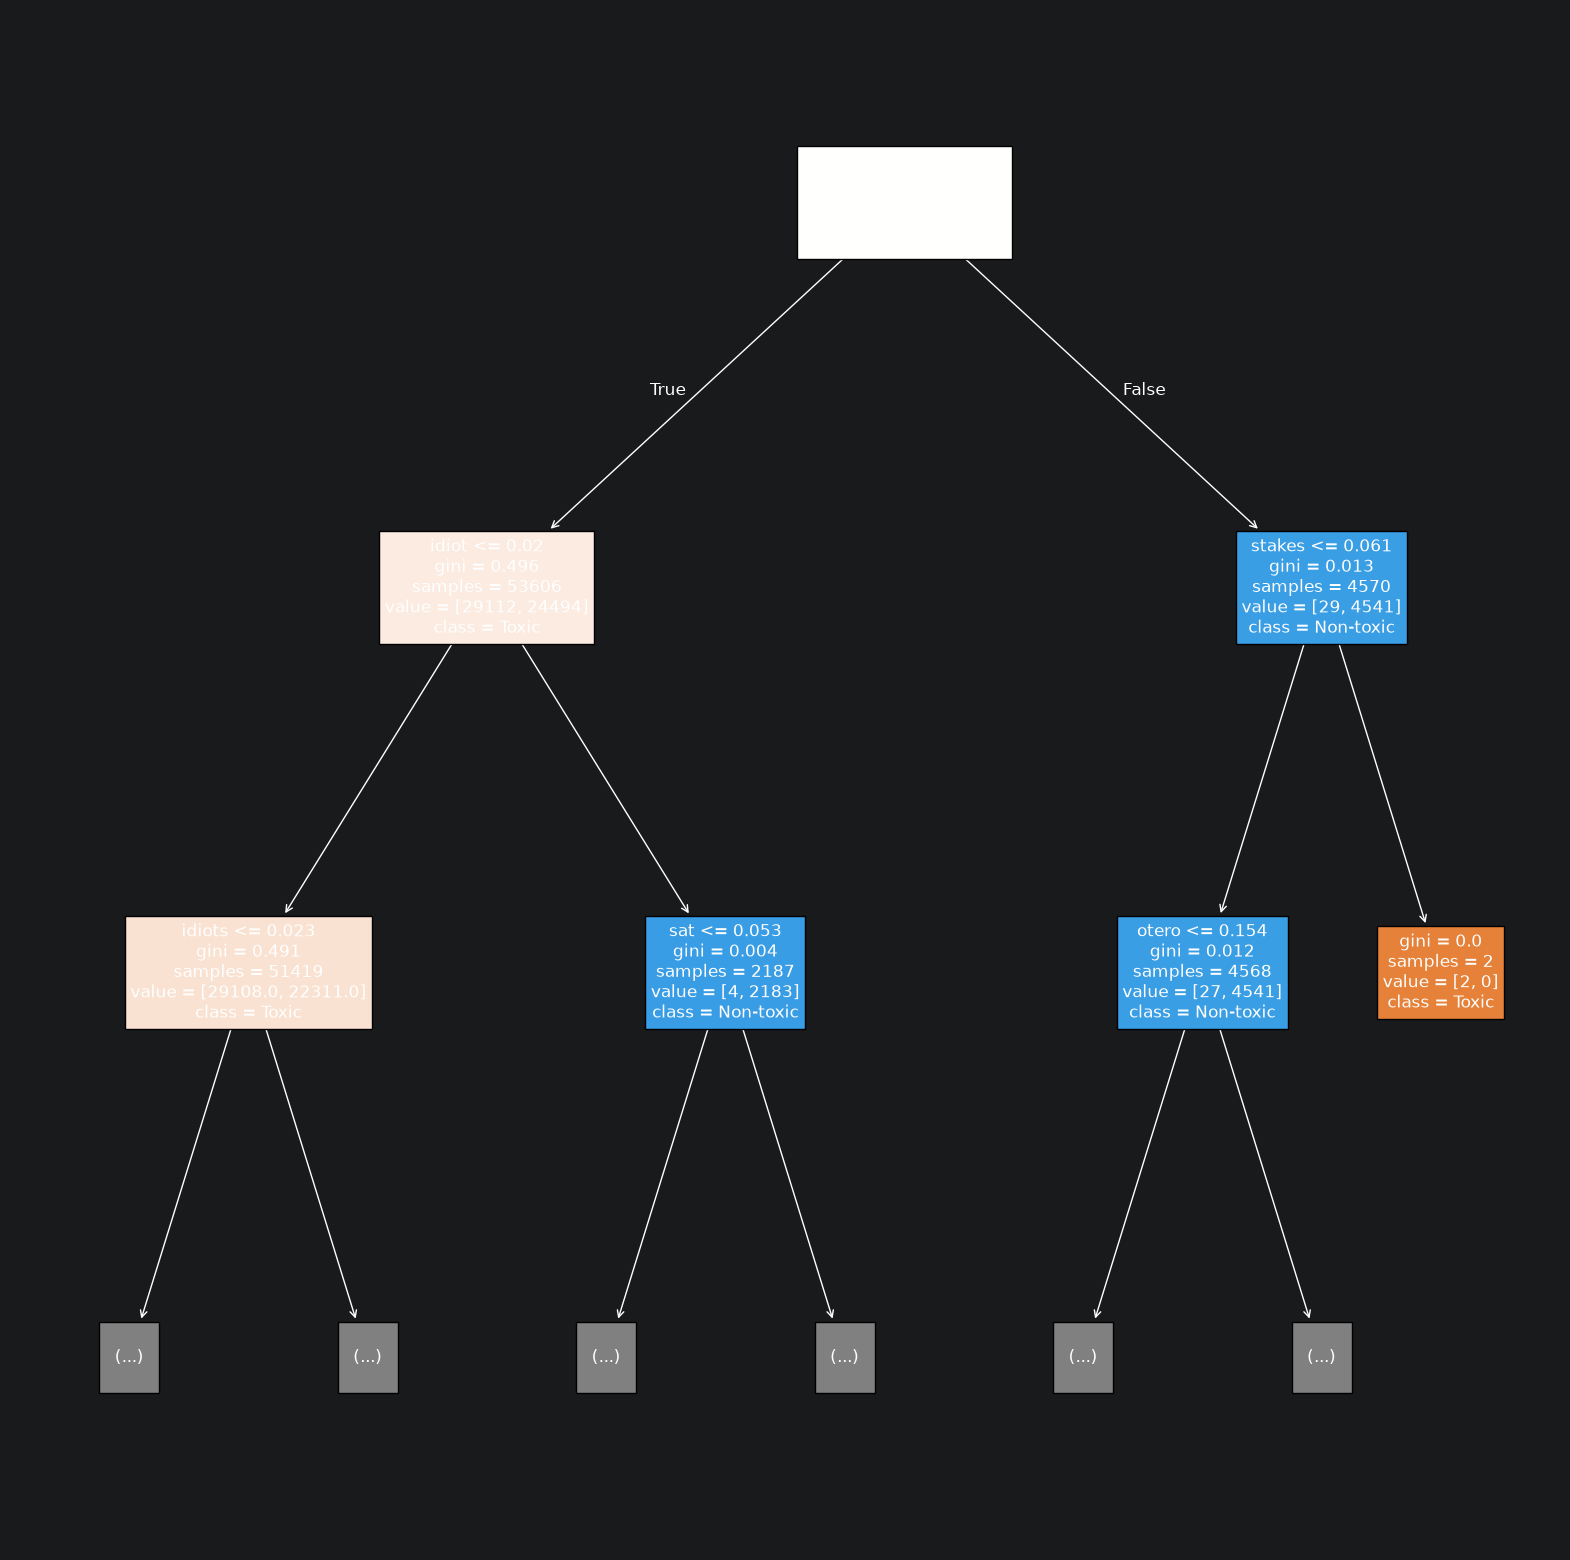

In [47]:
plt.figure(figsize=(20,20))
plot_tree(decision_tree=tree_model, filled=True,
          feature_names=tfidf.get_feature_names_out(),
          max_depth=2,
          fontsize=12,
          class_names=['Toxic','Non-toxic']);

We can see the tree splits the dataset based on specific conditions:
+ **gini**: shows how mixed are the toxic comments, the higher the value, the more confused it is. When gini = 0.0 it achieves total purity with no mix.
+ **word**: the tree focus on a specific word weight and presence comparing it with a value. If the text meets that condition, it proceeds along the left branch.
+ **samples**: total of comments that arrived to that box decision.
+ **value**: it reveals how many comments belong to each category.
+ **classes**: the winning result by a majority. The orange-tinted boxes indicate that the text is toxic and the blue ones indicate non-toxic.

In [30]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "max_depth": [None, 50, 100, 150, 200],
    "min_samples_split": [5, 20, 40, 60, 80, 100],
    "min_samples_leaf": [5, 20, 40, 60, 80, 100],
    "criterion": ["gini", "entropy","log_loss"],
}

random_search = RandomizedSearchCV(
    estimator=tree_model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

print(f"Best params: {random_search.best_params_}\n")
print(f"Best score: {random_search.best_score_}")

Best params: {'min_samples_split': 100, 'min_samples_leaf': 5, 'max_depth': 100, 'criterion': 'gini'}

Best score: 0.8815941848404478


So now lets decrease and adjust the ranges to see if we can improve the f1-score.

In [31]:
params = {
    "max_depth": [90, 95, 100, 110, 115, 120],
    "min_samples_split": [90, 95, 100, 110, 115, 120],
    "min_samples_leaf": [2, 3, 5, 7, 10, 15, 19],
    "criterion": ["gini"],
}

random_search = RandomizedSearchCV(
    estimator=tree_model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

print(f"Best params: {random_search.best_params_}\n")
print(f"Best score: {random_search.best_score_}")

Best params: {'min_samples_split': 115, 'min_samples_leaf': 2, 'max_depth': 115, 'criterion': 'gini'}

Best score: 0.8846109588576647


We didn´t improve the f1-score with random search method, we still have more fake positives, approximately 12% of predicted toxic comments are non-toxic.

### Random Forest

Lets try to improve the f1-score with random forest, training a bunch of decision tree on random subsets of comments and words to capture non-linear combinations.

In [32]:
from sklearn.ensemble import RandomForestClassifier


forest_model = RandomForestClassifier(random_state=42)

forest_model.fit(X_train,y_train)
y_pred_forest = forest_model.predict(tfidf.transform(X_val))

print(f"Accuracy: {accuracy_score(y_val, y_pred_forest):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_forest))

Accuracy: 0.8659

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.92      0.87      7293
        True       0.91      0.81      0.86      7252

    accuracy                           0.87     14545
   macro avg       0.87      0.87      0.87     14545
weighted avg       0.87      0.87      0.87     14545



The f1-score is worse than a single decision tree, also, the model achieves a recall of 0.81, meaning it fails identifying approximately 19% of the actual toxic comments, worst than baseline model.

In [33]:
params = {
    "max_depth": [None, 5, 10, 15, 20],
    "n_estimators": [5, 10, 15, 20, 25, 30],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy","log_loss"],
}

random_search = RandomizedSearchCV(
    estimator=forest_model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

print(f"Best params: {random_search.best_params_}\n")
print(f"Best score: {random_search.best_score_}")

Best params: {'n_estimators': 30, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'log_loss'}

Best score: 0.8407965769438281


### Naive Bayes

Lets try to use this basic probabilistic model that calculates word likelihoods assuming features follow a continuous, normal distribution.

In [34]:
from sklearn.naive_bayes import GaussianNB

naive_model = GaussianNB()
naive_model.fit(X_train.toarray(),y_train)
y_pred_naive = naive_model.predict(tfidf.transform(X_val).toarray())

print(f"Accuracy: {accuracy_score(y_val, y_pred_naive):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_naive))

Accuracy: 0.5803

Classification Report:
              precision    recall  f1-score   support

       False       0.67      0.32      0.44      7293
        True       0.55      0.84      0.67      7252

    accuracy                           0.58     14545
   macro avg       0.61      0.58      0.55     14545
weighted avg       0.61      0.58      0.55     14545



The accuracy is approximately 58%, it means our text TF-IDF scores are not a normal distribution, mostly zeros and discrete counts, so it is not useful for the goal.

So lets try MultinomialNB that is the specialized version of Naive Bayes for text and count data.

In [35]:
from sklearn.naive_bayes import MultinomialNB

multiNB_model = MultinomialNB()
multiNB_model.fit(X_train.toarray(),y_train)
y_pred_multiNB = multiNB_model.predict(tfidf.transform(X_val).toarray())

print(f"Accuracy: {accuracy_score(y_val, y_pred_multiNB):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_multiNB))

Accuracy: 0.8545

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.82      0.85      7293
        True       0.83      0.89      0.86      7252

    accuracy                           0.85     14545
   macro avg       0.86      0.85      0.85     14545
weighted avg       0.86      0.85      0.85     14545



We can see we have more f1-score approximately 86%, so it treats the word presence properly, but the model achieves a recall of 0.89, meaning approximately 11% of the predicted toxic are non-toxic, still worse than baseline model.

### SVM Model

Linear svc will find the widest margin, hyperplane, separating toxic from non-toxic comments. I'm using it because it is a standard for classic NLP and TF-IDF.

In [36]:
from sklearn import svm

LinearSvc_model = svm.LinearSVC(random_state=42)
LinearSvc_model.fit(X_train,y_train)

y_pred_svc = LinearSvc_model.predict(tfidf.transform(X_val))
print(f"Accuracy: {accuracy_score(y_val, y_pred_svc):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_svc))

Accuracy: 0.9328

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.93      7293
        True       0.96      0.91      0.93      7252

    accuracy                           0.93     14545
   macro avg       0.93      0.93      0.93     14545
weighted avg       0.93      0.93      0.93     14545



The f1-score is 0.93 way better than the models we have tried, also it achieves a recall of 0.96 meaning approximately 4% of the predicted toxic are non-toxic, still worse than baseline model

## Final model

Lets compare all the models, including the baseline.

In [52]:
from sklearn.metrics import f1_score, recall_score

models = {
    "Logistic Regression (Baseline)": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest,
    "Naive Bayes": y_pred_naive,
    "Multinomial Naive Bayes": y_pred_multiNB,
    "Linear SVC (SVM)": y_pred_svc
}

data = []
for name,prediction in models.items():
    data.append(
        {
            "name": name,
            "recall (True)": recall_score(y_val, prediction, pos_label=True),
            "f1-score":f1_score(y_val, prediction, average="macro")
        }
    )

df_models = pd.DataFrame(data).sort_values(by="f1-score", ascending=False)

df_models

,name,recall (True),f1-score
5,Linear SVC (SVM),0.907336,0.932708
0,Logistic Regression (Baseline),0.876586,0.918231
1,Decision Tree,0.877689,0.882016
2,Random Forest,0.812603,0.865517
4,Multinomial Naive Bayes,0.889961,0.854293
3,Naive Bayes,0.837562,0.551093


As we can see the best model for classifying text as toxic or non-toxic is `Linear SVC`, the standard for this type of classification, but we cannot forget about logistic regresion, a basic model that is really near Linear SVC

## Test

Once we selected the model, lets test it.

In [53]:
y_pred_test = LinearSvc_model.predict(tfidf.transform(X_test))

print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_test))

Accuracy: 0.9311

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.93      9017
        True       0.96      0.90      0.93      9164

    accuracy                           0.93     18181
   macro avg       0.93      0.93      0.93     18181
weighted avg       0.93      0.93      0.93     18181



The f1-score is approximately 93%, same as validation, also the recall is 0.96 so only 4% of the predicted toxic comments are non-toxic.

Also, we can trust accuracy as the data is balanced near 50/50.